In [1]:
import pandas as pd
from tqdm import tqdm
import os
import datetime as dt
import sys
import glob

In [2]:
sys.path.append("/data/workspace/libs/pytools")
db_dir = "/data/workspace/Data/DataBase"
from mfrt.research_tools import DBTool

In [3]:
from mfrt.opt_backtest import OptBacktest
from mfrt.eval_netvalue import EvalNetValue
opt_bt=OptBacktest(db_dir)
eval_NV=EvalNetValue(db_dir)

from mfrt.eval_factor import EvalFactor
eval_F = EvalFactor(db_dir)

check_Barra_list=('BETA', 'MOMENTUM', 'SIZE', 'RESVOL', 'BTOP', 'LIQUIDTY',  'SPRET', 'SIZENL', 'GROWTH', 'LEVERAGE')
def test_factor(factor: pd.DataFrame, 
                start_dt, 
                end_dt, 
                display: bool=False, 
                if_trade_tmr: bool=True, 
                specific_return: bool=True,
                Universe=['hs300'],
                return_type='Vwap') -> dict:
    F_res=eval_F.quick_test(factor,start_dt=start_dt,end_dt=end_dt,Group_Num=10,Horizon=10,Return_Type=return_type,
                        Specific_Return=specific_return,Universe=Universe,check_Barra_list=check_Barra_list,
                        extraExp_check_dict=None,if_trade_tmr=if_trade_tmr, display=display)
    
    return F_res

In [12]:
df = pd.read_parquet("/home/intern_fjq_2026/Projects/chinese-wwm-roberta/artifacts/continuous_label_layer_probe/runs/static_fy0_csi300_2025h1_v1/dense_residual_test_exploration_v1/dense_factor_panel.parquet")
result = df[
    (df["method"] == "decay_20d_hl10") & 
    (df["layer"] == 11) &
    (df["source_split"] == "test")
][["trading_date", "symbol", "factor_value"]]

In [13]:
result

,trading_date,symbol,factor_value
94465,2025-01-03,000063,-0.046484
94468,2025-01-03,000333,-0.359369
94474,2025-01-03,000596,-0.104224
94477,2025-01-03,000651,0.167791
94479,2025-01-03,000786,-0.143059
...,...,...,...
125679,2025-08-01,688256,-0.144136
125680,2025-08-01,688271,-0.049456
125681,2025-08-01,688303,-0.116253
125682,2025-08-01,688506,-0.166624


In [14]:
factor_wide = result.set_index(['trading_date', 'symbol'])['factor_value'].unstack()
factor_wide.index.name = 'date' 

In [15]:
counts = ((factor_wide != 0) & factor_wide.notna()).sum(axis=1)
counts

date
2025-01-03     41
2025-01-06     55
2025-01-07     98
2025-01-08    105
2025-01-09    110
             ... 
2025-07-28    178
2025-07-29    175
2025-07-30    174
2025-07-31    172
2025-08-01    174
Length: 140, dtype: int64

In [16]:
import pandas as pd

# 自动添加后缀：6开头加.SH，其他加.SZ
def add_suffix(col_code):
    if str(col_code).startswith('6'):
        return col_code + '.SH'
    else:
        return col_code + '.SZ'

factor_wide.index.name = 'date' # 确保行索引有名字
factor_wide.columns = [add_suffix(c) for c in factor_wide.columns]

# print(factor_wide.head()) # 检查一下表头是否变成了 000032.SZ

In [17]:
# 转换为时间戳并升序排列
factor_wide.index = pd.to_datetime(factor_wide.index)
factor_wide = factor_wide.sort_index()

print(f"日期范围：{factor_wide.index.min()} 到 {factor_wide.index.max()}")

日期范围：2025-01-03 00:00:00 到 2025-08-01 00:00:00


,IC,ICIR,Coverage,AutoCorr,LS_AnnRtn,LS_Sharpe,LS_AnnRtn_RbyH,LS_Sharpe_RbyH
0,6.55%,1.048,68.2%,87.8%,-8.7%,-1.00,11.4%,1.64


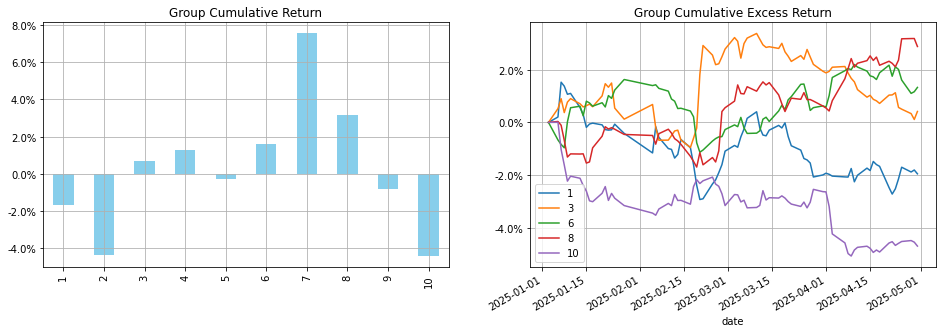

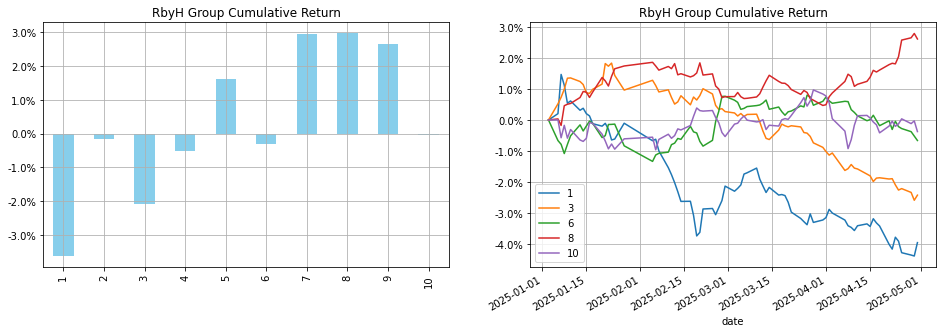

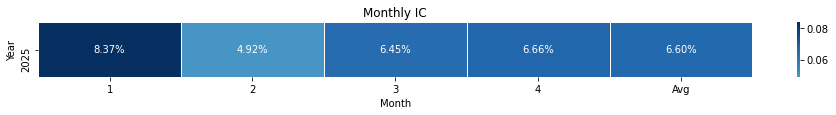

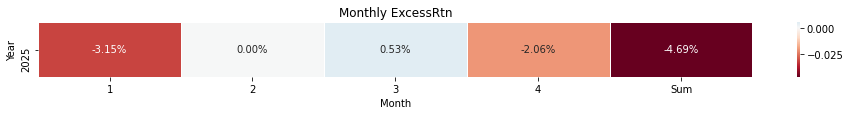

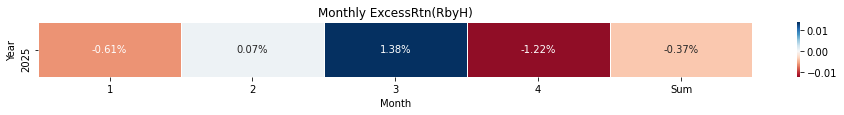

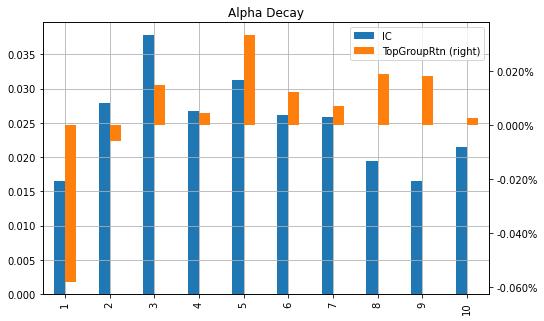

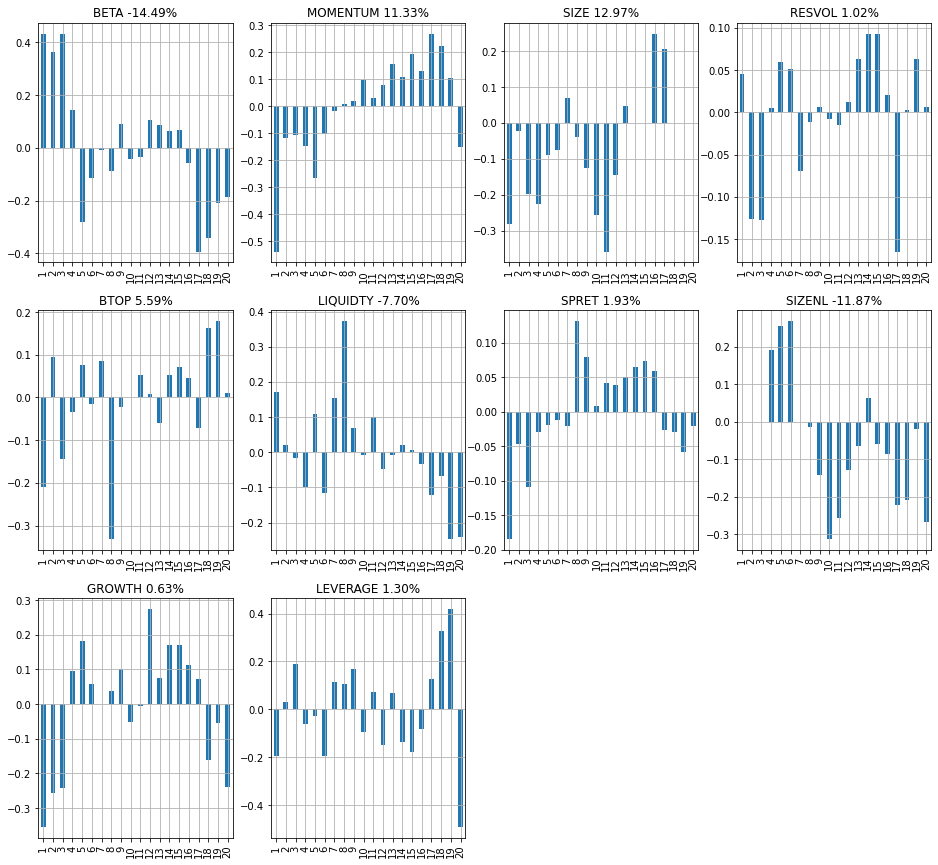

In [19]:
res = test_factor(
            factor_wide.dropna(how="all", axis=0),
            start_dt='2025.01.03',
            end_dt='2025.05.01',
            display=True,
            if_trade_tmr=True,
            specific_return=True,
            return_type="Vwap",
        )
res